# Predict admissions from age using MSOA binned by IMD

Skip the health demographics and use fewer IMD bands than before.

Split the demographics data by IMD score to improve the correlation between the other variables.

Age proportions: proportion of patients in each age band.
Health proportions: proportion of patients with each of good, fair, and bad health.

There are two steps to predicting admission numbers in each IMD band:
+ Use the age-health fits to predict health proportions.
  + Each age band gives a separate set of health proportions from the age-health fits.
  + Combining the sets of health proportions with the known age proportions gives the health proportions across the whole MSOA.
+ Use the predicted health proportions with the health-admissions fits to predict admissions.

Both of these prediction steps use a linear regression.

## Code setup

In [21]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [22]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [23]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [24]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [25]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [26]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [27]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [28]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [29]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [30]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [31]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [32]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [33]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [34]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [35]:
# Make columns for the results with a placeholder value:
df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[list(dict_quantiles.keys())[q+1]]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(q0)         # replace with bin min
        .otherwise(pl.col('imd_bin_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(q1)         # replace with bin min
        .otherwise(pl.col('imd_bin_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [36]:
df_stats[['IMD2019Score', 'imd_bin_min', 'imd_bin_max']]

IMD2019Score,imd_bin_min,imd_bin_max
f64,f64,f64
16.924833,15.2564,21.81475
6.4704,2.2122,10.369
13.7334,10.369,15.2564
26.199857,21.81475,31.84075
11.7948,10.369,15.2564
…,…,…
3.25925,2.2122,10.369
7.29475,2.2122,10.369
12.117,10.369,15.2564


## Admissions from age bands: calculate line equations

Use the `scipy.optimize` function instead of the `statsmodels` because with `optimize` we can place bounds on the resulting coefficients. In this case we force all coefficients to be between 0 and 1 so that we can consider them as probabilities.

Calculate optimised coefficients for the following:

$$ a = \Sigma c_a n_a$$

for admissions $a$, coefficients $c$, numbers of patients $n$, and age band $a$.

Note that there is no constant in the equation. When the number of patients with good, fair and bad health is zero, the number of admissions is zero.

The following function multiplies the coefficients by the numbers of patients and sums the result:

In [37]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [38]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return sum_sqres

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [39]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

The following function combines the previous ones to do the main calculations we need:

In [40]:
def main_admissions(coeffs, args):
    x_lists = args[0]
    admissions = args[1]
    yhat = predict_admissions(x_lists, coeffs)
    # Use only one of the following options for checking the fit:
    # sum_sqres = find_square_residuals(yhat, admissions)
    sum_sqres = find_mean_abs_diff(yhat, admissions)
    return sum_sqres

To check accuracy, the following function calculates R-squared:

In [41]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

Predict the admissions numbers for all IMD bands:

In [22]:
# Store the results in this list:
list_dict_admissions_lines = []

q = 0
for quantile_right_prop, quantile_left in imd_bin_left_edges.items():
    mask = (df_stats['imd_bin_min'] == quantile_left)
    quantile_right = dict_quantiles[list(dict_quantiles.keys())[q + 1]]
    quantile_left_prop = list(dict_quantiles.keys())[q + 1]
    # Keep only those MSOA:
    df_stats_here = df_stats.filter(mask)

    # Set up data for the optimiser.
    # Initial guess for health coefficients:
    # age_coeffs = [4e-4, 8e-4, 1e-3, 4e-3, 1.5e-2]  #[0.01 for a in age_numbers]
    age_coeffs = [4e-4, 5e-4, 2e-3, 6e-3, 1.7e-2]  #[0.01 for a in age_numbers]
    #     0.00005,  # P(stroke | good health)
    #     0.005,    # P(stroke | fair health)
    #     0.005     # P(stroke | bad health)
    # ]
    # MSOA data in the same order as those coefficients:
    x_lists = [df_stats_here[a] for a in age_numbers]
    # x_lists = [df_stats_here['good_health'], df_stats_here['fair health'], df_stats_here['bad health']]
    # Data for the optimiser function that should not be changed:
    args = [
        x_lists,
        df_stats_here['admissions']
    ]
    # Run the optimiser:
    opt_results = minimize(
        main_admissions,
        x0=age_coeffs,
        args=args,
        bounds=[(0.0, 1.0)] * len(age_coeffs),  # force results to lie between 0 and 1
        method='Nelder-Mead'
        # method='SLSQP',
    )
    # Pick out the resulting health coefficients:
    coeffs = opt_results['x']
    # Use these coefficients to predict the admissions and so
    # calculate r-squared for accuracy of the fit.
    admissions_predicted = predict_admissions(x_lists, coeffs)
    r2 = calculate_rsquared(df_stats_here['admissions'], admissions_predicted)

    # Store the results in a dictionary:
    dict_admissions_lines = {}
    dict_admissions_lines['depriv_quantile_min'] = quantile_left_prop
    dict_admissions_lines['depriv_quantile_max'] = quantile_right_prop
    dict_admissions_lines['imd_bin_min'] = quantile_left
    dict_admissions_lines['imd_bin_max'] = quantile_right
    for i, a in enumerate(age_numbers):
        dict_admissions_lines[f'coeff_{a}'] = round(coeffs[i], 7)
        # dict_admissions_lines['coeff_fair_health'] = round(coeffs[1], 7)
        # dict_admissions_lines['coeff_bad_health'] = round(coeffs[2], 7)
    dict_admissions_lines['rsquared'] = round(r2, 7)
    # Store in big list of all results:
    list_dict_admissions_lines.append(dict_admissions_lines)
    # Iterate for next go round the loop:
    q += 1

# Convert the list of dicts into a dataframe:
df_admissions_lines = pl.from_dicts(list_dict_admissions_lines)

Check the results:

In [23]:
df_admissions_lines

depriv_quantile_min,depriv_quantile_max,imd_bin_min,imd_bin_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.8,1.0,2.2122,10.369,0.0002225,0.0007558,0.002468,0.0029374,0.0154785,0.6268621
0.6,0.8,10.369,15.2564,0.0003312,0.0004144,0.0027401,0.0055523,0.0143601,0.6121834
0.4,0.6,15.2564,21.81475,0.0004109,0.0007421,0.0007305,0.0055545,0.0168326,0.6430947
0.2,0.4,21.81475,31.84075,0.0005012,0.0019855,0.0058598,0.0005873,0.0156725,0.5802961
0.0,0.2,31.84075,87.02675,0.0006132,0.0,0.0105124,0.0,0.0164129,0.4950798


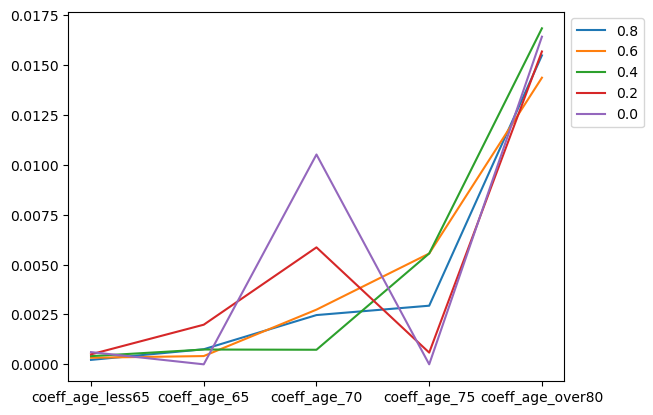

In [24]:
age_cols_to_plot = [c for c in df_admissions_lines.columns if 'coeff_age' in c]

df = df_admissions_lines[age_cols_to_plot].transpose()

fig, ax = plt.subplots()
for i, row in enumerate(df):
    ax.plot(row, label=df_admissions_lines['depriv_quantile_min'][i])

ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
ax.set_xticks(np.arange(len(row)))
ax.set_xticklabels(age_cols_to_plot)
plt.show()

Store a copy:

In [25]:
df_admissions_lines.write_csv(os.path.join('outputs', 'line_fits_ageonly_to_admissions_imd5.csv'))

## Run grid of starting coeffs

To check we're not stuck in local minimum.

Options for each coeff:

In [26]:
coeff_options = [1e-4, 4e-4, 7e-4, 1e-3, 4e-3, 7e-3, 1e-2]

Set up the bounding values for each start option:

In [54]:
bounds_dict = {
    str(float(1e-4)): {'min': 7e-5, 'max': 4e-4},
    str(float(4e-4)): {'min': 1e-4, 'max': 7e-4},
    str(float(7e-4)): {'min': 4e-4, 'max': 1e-3},
    str(float(1e-3)): {'min': 7e-4, 'max': 4e-3},
    str(float(4e-3)): {'min': 1e-3, 'max': 7e-3},
    str(float(7e-3)): {'min': 4e-3, 'max': 1e-2},
    str(float(1e-2)): {'min': 9e-3, 'max': 2e-2},
}

In [55]:
bounds_dict

{'0.0001': {'min': 7e-05, 'max': 0.0004},
 '0.0004': {'min': 0.0001, 'max': 0.0007},
 '0.0007': {'min': 0.0004, 'max': 0.001},
 '0.001': {'min': 0.0007, 'max': 0.004},
 '0.004': {'min': 0.001, 'max': 0.007},
 '0.007': {'min': 0.004, 'max': 0.01},
 '0.01': {'min': 0.009, 'max': 0.02}}

Find each combination of these starting coeffs for 5 coeffs:

In [27]:
from itertools import product

In [28]:
start_options = [i for i in product(*[coeff_options]*5)]

In [29]:
len(start_options)

16807

In [30]:
start_options[:10]

[(0.0001, 0.0001, 0.0001, 0.0001, 0.0001),
 (0.0001, 0.0001, 0.0001, 0.0001, 0.0004),
 (0.0001, 0.0001, 0.0001, 0.0001, 0.0007),
 (0.0001, 0.0001, 0.0001, 0.0001, 0.001),
 (0.0001, 0.0001, 0.0001, 0.0001, 0.004),
 (0.0001, 0.0001, 0.0001, 0.0001, 0.007),
 (0.0001, 0.0001, 0.0001, 0.0001, 0.01),
 (0.0001, 0.0001, 0.0001, 0.0004, 0.0001),
 (0.0001, 0.0001, 0.0001, 0.0004, 0.0004),
 (0.0001, 0.0001, 0.0001, 0.0004, 0.0007)]

Only keep options where start values are reasonable:

In [39]:
n = np.array(start_options)

mask = (
    np.isin(n[:, 0], [0.0001, 0.0004, 0.0007]) &
    np.isin(n[:, 1], [0.0007, 0.001, 0.004]) &
    np.isin(n[:, 2], [0.0007, 0.001, 0.004]) &
    np.isin(n[:, 3], [0.0007, 0.001, 0.004]) &
    np.isin(n[:, 4], [0.007, 0.01])
)

start_options = np.array(start_options)[mask]
start_options = list(start_options)

In [41]:
len(start_options)

162

Place these into a DataFrame:

In [50]:
pl.DataFrame(start_options, orient='row', schema=[f'{c}_start' for c in age_numbers])

age_less65_start,age_65_start,age_70_start,age_75_start,age_over80_start
f64,f64,f64,f64,f64
0.0001,0.0007,0.0007,0.0007,0.007
0.0001,0.0007,0.0007,0.0007,0.01
0.0001,0.0007,0.0007,0.001,0.007
0.0001,0.0007,0.0007,0.001,0.01
0.0001,0.0007,0.0007,0.004,0.007
…,…,…,…,…
0.0007,0.004,0.004,0.0007,0.01
0.0007,0.004,0.004,0.001,0.007
0.0007,0.004,0.004,0.001,0.01


For each set of starting coefficients, find the r^2 of their predicted admissions fits and then find the optimised coefficients and their r^2 fit.

In [56]:
# Store the results in this list:
list_dict_admissions_lines = []

for ind_start, age_coeffs in enumerate(start_options):
    print(f'{ind_start:8.0f}', end='\r')
    q = 0
    for quantile_right_prop, quantile_left in imd_bin_left_edges.items():
        mask = (df_stats['imd_bin_min'] == quantile_left)
        quantile_right = dict_quantiles[list(dict_quantiles.keys())[q + 1]]
        quantile_left_prop = list(dict_quantiles.keys())[q + 1]
        # Keep only those MSOA:
        df_stats_here = df_stats.filter(mask)
    
        # Set up data for the optimiser.
        # Initial guess for health coefficients:
        # age_coeffs = [4e-4, 8e-4, 1e-3, 4e-3, 1.5e-2]  #[0.01 for a in age_numbers]
        # age_coeffs = [4e-4, 7e-3, 8e-3, 9e-3, 1e-2]  #[0.01 for a in age_numbers]
        #     0.00005,  # P(stroke | good health)
        #     0.005,    # P(stroke | fair health)
        #     0.005     # P(stroke | bad health)
        # ]
        # MSOA data in the same order as those coefficients:
        x_lists = [df_stats_here[a] for a in age_numbers]
        # x_lists = [df_stats_here['good_health'], df_stats_here['fair health'], df_stats_here['bad health']]
        # Data for the optimiser function that should not be changed:
        args = [
            x_lists,
            df_stats_here['admissions']
        ]

        # Results without optimisation:
        admissions_predicted = predict_admissions(x_lists, np.array(age_coeffs))
        r2_without_opt = calculate_rsquared(df_stats_here['admissions'], admissions_predicted)

        bounds_here = [(bounds_dict[str(float(a))]['min'], bounds_dict[str(float(a))]['max']) for a in age_coeffs]
        
        # Run the optimiser:
        opt_results = minimize(
            main_admissions,
            x0=age_coeffs,
            args=args,
            # bounds=[(0.0, 1.0)] * len(age_coeffs),  # force results to lie between 0 and 1
            bounds=bounds_here,
            method='Nelder-Mead'
            # method='SLSQP',
        )
        # Pick out the resulting health coefficients:
        coeffs = opt_results['x']
        # Use these coefficients to predict the admissions and so
        # calculate r-squared for accuracy of the fit.
        admissions_predicted = predict_admissions(x_lists, coeffs)
        r2 = calculate_rsquared(df_stats_here['admissions'], admissions_predicted)
    
        # Store the results in a dictionary:
        dict_admissions_lines = {}
        dict_admissions_lines['start_option'] = ind_start
        dict_admissions_lines['depriv_quantile_min'] = quantile_left_prop
        dict_admissions_lines['depriv_quantile_max'] = quantile_right_prop
        # dict_admissions_lines['imd_bin_min'] = quantile_left
        # dict_admissions_lines['imd_bin_max'] = quantile_right
        for i, a in enumerate(age_numbers):
            dict_admissions_lines[f'start_coeff_{a}'] = round(age_coeffs[i], 7)
        dict_admissions_lines['rsquared_without_opt'] = r2_without_opt
        for i, a in enumerate(age_numbers):
            dict_admissions_lines[f'coeff_{a}'] = round(coeffs[i], 7)
            # dict_admissions_lines['coeff_fair_health'] = round(coeffs[1], 7)
            # dict_admissions_lines['coeff_bad_health'] = round(coeffs[2], 7)
        dict_admissions_lines['rsquared'] = round(r2, 7)
        # Store in big list of all results:
        list_dict_admissions_lines.append(dict_admissions_lines)
        # Iterate for next go round the loop:
        q += 1

# Convert the list of dicts into a dataframe:
df_admissions_lines_very_many = pl.from_dicts(list_dict_admissions_lines)

In [57]:
df_admissions_lines_very_many

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.8,1.0,0.0001,0.0007,0.0007,0.0007,0.007,-1.758813,0.0004,0.001,0.001,0.001,0.01,0.1081506
0,0.6,0.8,0.0001,0.0007,0.0007,0.0007,0.007,-2.245089,0.0004,0.001,0.001,0.001,0.01,-0.184314
0,0.4,0.6,0.0001,0.0007,0.0007,0.0007,0.007,-2.238987,0.0004,0.001,0.001,0.001,0.01,-0.286964
0,0.2,0.4,0.0001,0.0007,0.0007,0.0007,0.007,-2.900872,0.0004,0.001,0.0004,0.001,0.01,-0.809578
0,0.0,0.2,0.0001,0.0007,0.0007,0.0007,0.007,-4.019878,0.0004,0.001,0.0004,0.0004,0.01,-1.616865
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
161,0.8,1.0,0.0007,0.004,0.004,0.004,0.01,0.263779,0.0004,0.0010594,0.0010061,0.0034212,0.014194,0.6233367
161,0.6,0.8,0.0007,0.004,0.004,0.004,0.01,0.457451,0.0004019,0.0010505,0.001,0.0069877,0.0136058,0.6136522
161,0.4,0.6,0.0007,0.004,0.004,0.004,0.01,0.567996,0.0004043,0.0010272,0.001,0.007,0.0153732,0.643079


Save a copy of these results:

In [58]:
df_admissions_lines_very_many.write_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_bounds.csv'))

In [314]:
df_admissions_lines_very_many = pl.read_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5.csv'))

In [315]:
df_admissions_lines_very_many.head()

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.8,1.0,0.0001,0.0001,0.0001,0.0001,0.0001,-5.734182,0.000337,0.0,0.0000393,0.0000596,0.019059,0.619094
0,0.6,0.8,0.0001,0.0001,0.0001,0.0001,0.0001,-6.214993,0.001879,0.0,0.0000001,0.0000417,0.0002908,-0.111638
0,0.4,0.6,0.0001,0.0001,0.0001,0.0001,0.0001,-5.616916,0.0005123,0.0,0.0012095,0.0268129,0.0002671,0.5665965
0,0.2,0.4,0.0001,0.0001,0.0001,0.0001,0.0001,-6.017755,0.0016707,0.0002722,0.0,0.0000459,0.0000001,-0.296089
0,0.0,0.2,0.0001,0.0001,0.0001,0.0001,0.0001,-6.935945,0.001667,0.000267,0.0000001,0.0000489,0.0,-0.095337


Check whether any options give optimised coeffs that increase with age band for all IMD bands:

In [317]:
coeff_cols = [f'coeff_{a}' for a in age_numbers]

df_coeffs = df_admissions_lines_very_many[coeff_cols].transpose()

list_sorted = []
for c, col in enumerate(df_coeffs.columns):
    b = df_coeffs[col].is_sorted()
    list_sorted.append(b)

df_admissions_lines_very_many = df_admissions_lines_very_many.insert_column(len(df_admissions_lines_very_many.columns), pl.Series('opt_coeffs_sorted_by_age', list_sorted))

In [318]:
df_admissions_lines_very_many

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
0,0.8,1.0,0.0001,0.0001,0.0001,0.0001,0.0001,-5.734182,0.000337,0.0,0.0000393,0.0000596,0.019059,0.619094,false
0,0.6,0.8,0.0001,0.0001,0.0001,0.0001,0.0001,-6.214993,0.001879,0.0,0.0000001,0.0000417,0.0002908,-0.111638,false
0,0.4,0.6,0.0001,0.0001,0.0001,0.0001,0.0001,-5.616916,0.0005123,0.0,0.0012095,0.0268129,0.0002671,0.5665965,false
0,0.2,0.4,0.0001,0.0001,0.0001,0.0001,0.0001,-6.017755,0.0016707,0.0002722,0.0,0.0000459,0.0000001,-0.296089,false
0,0.0,0.2,0.0001,0.0001,0.0001,0.0001,0.0001,-6.935945,0.001667,0.000267,0.0000001,0.0000489,0.0,-0.095337,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
16806,0.8,1.0,0.01,0.01,0.01,0.01,0.01,-230.728008,0.0,0.0082236,0.0000039,0.0000366,0.015844,0.6180592,false
16806,0.6,0.8,0.01,0.01,0.01,0.01,0.01,-212.756433,0.0,0.006201,0.0,0.006953,0.014822,0.5805481,false
16806,0.4,0.6,0.01,0.01,0.01,0.01,0.01,-200.549304,0.0,0.0113138,0.0000009,0.0,0.0169524,0.608372,false


In [285]:
start_options_all_sorted = []

for start_option in df_admissions_lines_very_many['start_option'].unique():
    # Are all coeffs sorted:
    mask = df_admissions_lines_very_many['start_option'] == start_option
    df_here = df_admissions_lines_very_many.filter(mask)
    all_sorted = all(df_here['opt_coeffs_sorted_by_age'].to_numpy())
    if all_sorted:
        start_options_all_sorted.append(start_option)

In [286]:
start_options_all_sorted

[12487, 14930, 15278]

In [287]:
df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'].is_in(start_options_all_sorted))

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
12487,0.8,1.0,0.007,0.0004,0.0007,0.007,0.01,-79.207066,0.0002609,0.0003875,0.0004312,0.0067438,0.0145783,0.6250684,true
12487,0.6,0.8,0.007,0.0004,0.0007,0.007,0.01,-71.207656,0.0003561,0.0004363,0.0007238,0.0070846,0.0148358,0.6124041,true
12487,0.4,0.6,0.007,0.0004,0.0007,0.007,0.01,-69.093694,0.0004161,0.0004415,0.0007668,0.0058834,0.0167833,0.6429498,true
12487,0.2,0.4,0.007,0.0004,0.0007,0.007,0.01,-82.190709,0.0005282,0.0010188,0.0014722,0.0069154,0.0161811,0.5789034,true
12487,0.0,0.2,0.007,0.0004,0.0007,0.007,0.01,-93.972369,0.0006102,0.0013788,0.0020156,0.0055951,0.0194048,0.4867032,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
15278,0.8,1.0,0.01,0.0007,0.001,0.007,0.004,-156.725418,0.0002127,0.0009066,0.0026951,0.0037669,0.0146276,0.6262401,true
15278,0.6,0.8,0.01,0.0007,0.001,0.007,0.004,-143.560906,0.0003628,0.0006216,0.001777,0.0035461,0.016096,0.6131283,true
15278,0.4,0.6,0.01,0.0007,0.001,0.007,0.004,-142.322923,0.0004033,0.0005566,0.00247,0.0028997,0.0173143,0.6432523,true


depriv_quantile_min,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80
f64,f64,f64,f64,f64,f64
0.8,0.0002609,0.0003875,0.0004312,0.0067438,0.0145783
0.6,0.0003561,0.0004363,0.0007238,0.0070846,0.0148358
0.4,0.0004161,0.0004415,0.0007668,0.0058834,0.0167833
0.2,0.0005282,0.0010188,0.0014722,0.0069154,0.0161811
0.0,0.0006102,0.0013788,0.0020156,0.0055951,0.0194048


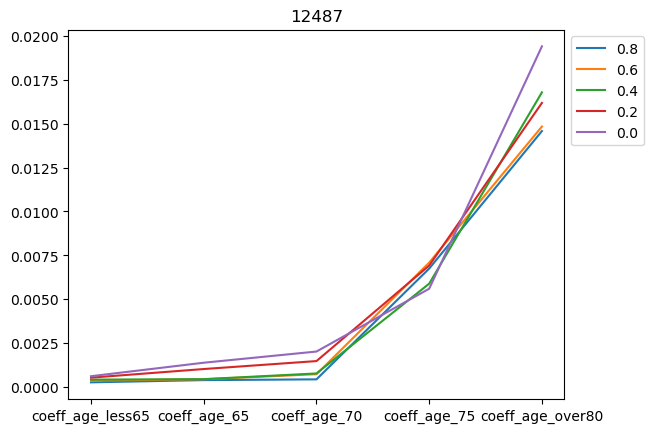

depriv_quantile_min,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80
f64,f64,f64,f64,f64,f64
0.8,0.0002432,0.0008316,0.0012061,0.0048237,0.0150172
0.6,0.0003473,0.0004127,0.0013796,0.0064214,0.0148314
0.4,0.000414,0.0005341,0.0013171,0.006148,0.0159428
0.2,0.0005237,0.0006422,0.0027557,0.0066295,0.0155072
0.0,0.0006315,0.000636,0.0024401,0.0101868,0.016228


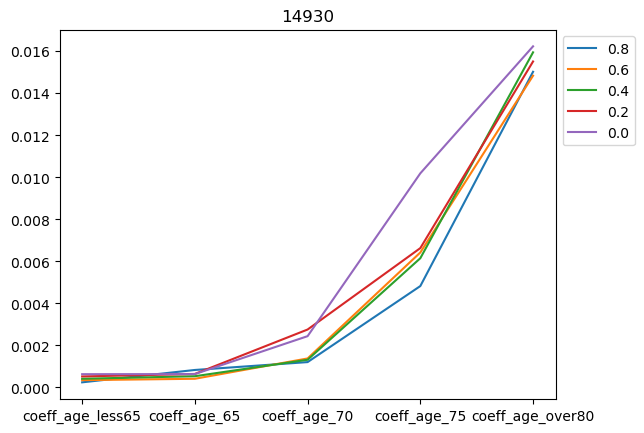

depriv_quantile_min,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80
f64,f64,f64,f64,f64,f64
0.8,0.0002127,0.0009066,0.0026951,0.0037669,0.0146276
0.6,0.0003628,0.0006216,0.001777,0.0035461,0.016096
0.4,0.0004033,0.0005566,0.00247,0.0028997,0.0173143
0.2,0.0005223,0.0008469,0.0029874,0.0059027,0.015611
0.0,0.0006265,0.0007596,0.0026452,0.007459,0.017912


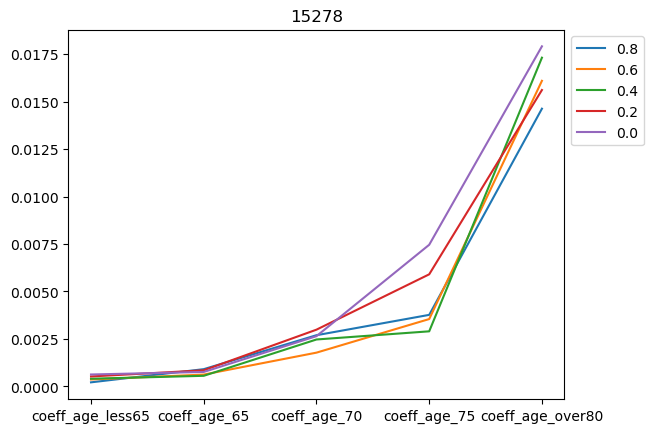

In [295]:
age_cols_to_plot = [c for c in df_admissions_lines_very_many.columns if (('coeff_age' in c) & ('start' not in c))]

for start_option in start_options_all_sorted:
    
    df = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option)
    quantile_mins = df['depriv_quantile_min']

    display(df[['depriv_quantile_min'] + age_cols_to_plot])
    df = df[age_cols_to_plot].transpose()

    
    fig, ax = plt.subplots()
    for i, row in enumerate(df):
        ax.plot(row, label=quantile_mins[i])
    
    ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
    ax.set_xticks(np.arange(len(row)))
    ax.set_xticklabels(age_cols_to_plot)
    ax.set_title(start_option)
    plt.show()

For each IMD band, pick out any options where age bands tick up and compare:

In [316]:
df_admissions_lines_very_many.head()

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.8,1.0,0.0001,0.0001,0.0001,0.0001,0.0001,-5.734182,0.000337,0.0,0.0000393,0.0000596,0.019059,0.619094
0,0.6,0.8,0.0001,0.0001,0.0001,0.0001,0.0001,-6.214993,0.001879,0.0,0.0000001,0.0000417,0.0002908,-0.111638
0,0.4,0.6,0.0001,0.0001,0.0001,0.0001,0.0001,-5.616916,0.0005123,0.0,0.0012095,0.0268129,0.0002671,0.5665965
0,0.2,0.4,0.0001,0.0001,0.0001,0.0001,0.0001,-6.017755,0.0016707,0.0002722,0.0,0.0000459,0.0000001,-0.296089
0,0.0,0.2,0.0001,0.0001,0.0001,0.0001,0.0001,-6.935945,0.001667,0.000267,0.0000001,0.0000489,0.0,-0.095337


In [320]:
quantile_mins

depriv_quantile_min
f64
0.8
0.6
0.4
0.2
0.0


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
10918,0.0,0.2,0.004,0.001,0.007,0.007,0.007,-25.056248,0.0007801,0.00112,0.0070708,0.008365,0.008487,0.475036,true
10084,0.0,0.2,0.004,0.0004,0.0007,0.007,0.004,-19.140353,0.0006311,0.0008185,0.0011603,0.0058926,0.0201963,0.4838744,true
10091,0.0,0.2,0.004,0.0004,0.0007,0.01,0.004,-20.291615,0.0006381,0.0007608,0.0011617,0.0076131,0.0189057,0.4850102,true
14611,0.0,0.2,0.01,0.0001,0.004,0.0004,0.0007,-193.999981,0.0006436,0.0013352,0.0014904,0.0135877,0.0136976,0.4855263,true
10042,0.0,0.2,0.004,0.0004,0.0004,0.01,0.004,-20.122787,0.000629,0.00079,0.000819,0.0123282,0.0163467,0.4855756,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
10355,0.0,0.2,0.004,0.0007,0.0004,0.0007,0.0007,-15.30698,0.0005624,0.0053195,0.0054376,0.0069671,0.0119841,0.4927134,true
15264,0.0,0.2,0.01,0.0007,0.001,0.001,0.004,-196.450721,0.0005667,0.004575,0.0056933,0.0069474,0.0124357,0.4927597,true
6093,0.0,0.2,0.0007,0.001,0.007,0.0007,0.001,-0.827285,0.0005706,0.0037707,0.0048321,0.0068039,0.0141366,0.4929604,true


/tmp/ipykernel_11689/1937081202.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')


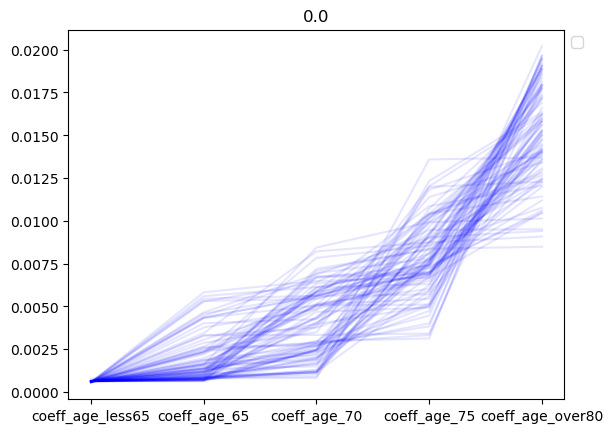

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
2351,0.2,0.4,0.0001,0.01,0.007,0.01,0.01,0.432571,0.0003047,0.0007561,0.0060128,0.0082152,0.0148732,0.547808,true
1712,0.2,0.4,0.0001,0.004,0.01,0.01,0.004,0.207134,0.00038,0.0026253,0.0070905,0.0078706,0.0106549,0.5611241,true
12968,0.2,0.4,0.007,0.0007,0.007,0.004,0.004,-80.244065,0.0005283,0.0009919,0.0063853,0.0090425,0.0097264,0.5728874,true
15026,0.2,0.4,0.01,0.0004,0.007,0.004,0.004,-180.649598,0.0005318,0.0006402,0.0066235,0.0092686,0.0096641,0.5729259,true
10863,0.2,0.4,0.004,0.001,0.004,0.004,0.01,-21.824033,0.0005563,0.0008091,0.0068023,0.0082006,0.0096182,0.5732671,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
10523,0.2,0.4,0.004,0.0007,0.004,0.007,0.0007,-17.187613,0.0004999,0.0023297,0.0038695,0.0043782,0.0146546,0.5800565,true
12871,0.2,0.4,0.007,0.0007,0.001,0.004,0.007,-76.476266,0.0005028,0.0023044,0.0025167,0.0042956,0.0160958,0.5801851,true
10819,0.2,0.4,0.004,0.001,0.001,0.007,0.004,-17.535386,0.0005301,0.001813,0.0021107,0.0026035,0.017906,0.5802414,true


/tmp/ipykernel_11689/1937081202.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')


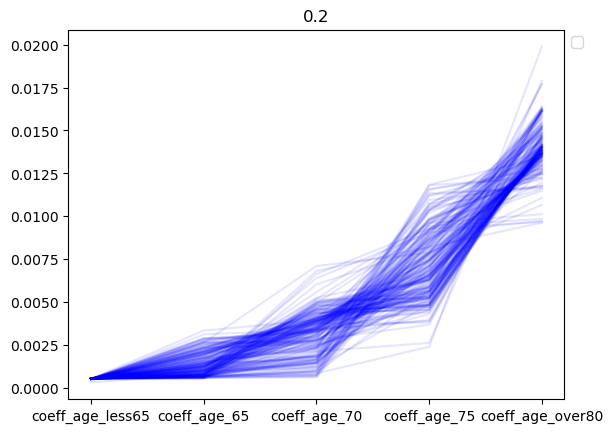

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
15311,0.4,0.6,0.01,0.0007,0.004,0.001,0.0007,-133.518808,0.0003563,0.0033915,0.0054162,0.0083198,0.0084053,0.6191637,true
10189,0.4,0.6,0.004,0.0004,0.004,0.01,0.004,-17.467422,0.0003868,0.0004076,0.0073516,0.0074874,0.0095712,0.6248395,true
14828,0.4,0.6,0.01,0.0004,0.0004,0.004,0.0007,-130.180413,0.0003648,0.0027157,0.0054901,0.0073176,0.0095527,0.6249823,true
14929,0.4,0.6,0.01,0.0004,0.001,0.004,0.007,-143.448858,0.0003918,0.0018003,0.0041822,0.0089954,0.0101232,0.6293158,true
14968,0.4,0.6,0.01,0.0004,0.004,0.001,0.0007,-132.952928,0.0003557,0.0028657,0.0040692,0.0071143,0.0110485,0.6315449,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1852,0.4,0.6,0.0001,0.007,0.0007,0.007,0.004,-0.364614,0.0003933,0.0019619,0.0020035,0.0027809,0.0166588,0.6437985,true
5724,0.4,0.6,0.0007,0.0007,0.004,0.007,0.007,0.548519,0.0004016,0.0014322,0.0019084,0.0026989,0.0172331,0.6438213,true
614,0.4,0.6,0.0001,0.0004,0.007,0.001,0.007,-0.613146,0.0004037,0.0015365,0.0019247,0.0025347,0.01721,0.6438472,true


/tmp/ipykernel_11689/1937081202.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')


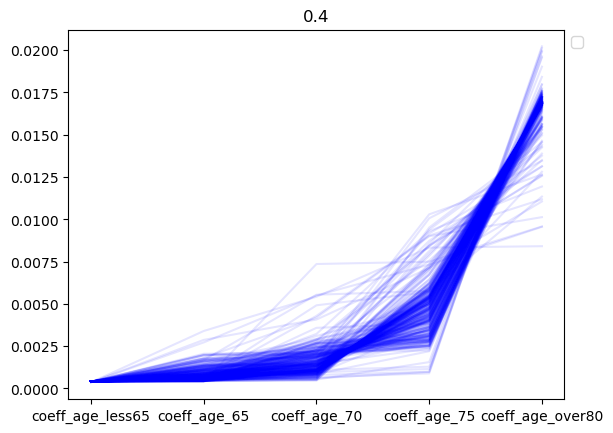

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
10618,0.6,0.8,0.004,0.0007,0.01,0.004,0.01,-25.830189,0.0,0.0023962,0.0027625,0.0069758,0.0155775,0.5739365,true
13019,0.6,0.8,0.007,0.0007,0.01,0.004,0.01,-84.270526,0.0,0.0023962,0.0027625,0.0069758,0.0155775,0.5739365,true
15420,0.6,0.8,0.01,0.0007,0.01,0.004,0.01,-175.87483,0.0,0.0023962,0.0027625,0.0069758,0.0155775,0.5739365,true
860,0.6,0.8,0.0001,0.0007,0.001,0.001,0.01,-1.101528,0.000116,0.0006848,0.0007124,0.0008412,0.0218753,0.5757777,true
14885,0.6,0.8,0.01,0.0004,0.0007,0.007,0.001,-135.200777,0.0003111,0.00148,0.0064248,0.007547,0.008614,0.5924836,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
15621,0.6,0.8,0.01,0.001,0.001,0.007,0.004,-144.238111,0.0003601,0.0006399,0.0019919,0.0038611,0.0157003,0.613427,true
2228,0.6,0.8,0.0001,0.01,0.001,0.001,0.0007,-1.402015,0.0003512,0.001318,0.0017771,0.0035818,0.015603,0.6134305,true
14186,0.6,0.8,0.007,0.01,0.0007,0.001,0.004,-69.271293,0.0003475,0.0013129,0.0018645,0.0035284,0.0156246,0.6134423,true


/tmp/ipykernel_11689/1937081202.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')


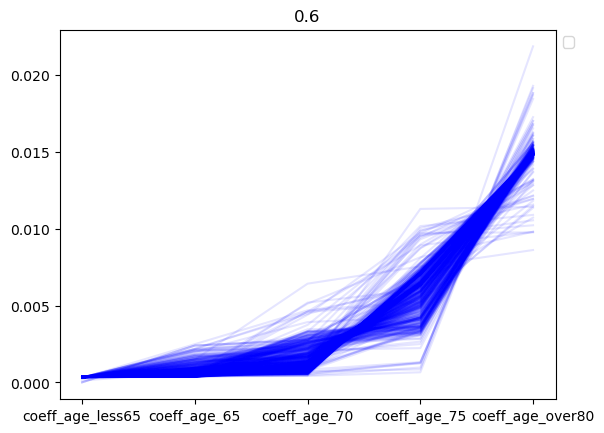

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,opt_coeffs_sorted_by_age
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
14503,0.8,1.0,0.01,0.0001,0.0004,0.01,0.01,-175.882131,0.0,0.0000812,0.0003835,0.0106629,0.0150682,0.5969488,true
14454,0.8,1.0,0.01,0.0001,0.0001,0.01,0.01,-175.074702,0.0,0.0000534,0.0001928,0.010021,0.0157745,0.5969939,true
15264,0.8,1.0,0.01,0.0007,0.001,0.001,0.004,-145.957818,0.0002055,0.0025622,0.0059485,0.0073755,0.0075756,0.5975429,true
1592,0.8,1.0,0.0001,0.004,0.004,0.001,0.001,-1.776261,0.0,0.0007542,0.0030412,0.0094297,0.012837,0.6012511,true
2271,0.8,1.0,0.0001,0.01,0.004,0.0007,0.001,-0.389041,0.0,0.0002473,0.003687,0.0087819,0.0131563,0.6015216,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6417,0.8,1.0,0.0007,0.004,0.004,0.01,0.007,0.086865,0.0002183,0.0017001,0.0021198,0.0029536,0.0149922,0.6272041,true
7139,0.8,1.0,0.0007,0.01,0.007,0.004,0.01,-1.610851,0.0002108,0.0018684,0.0019701,0.0028441,0.0151664,0.6272203,true
1994,0.8,1.0,0.0001,0.007,0.007,0.004,0.01,0.460249,0.000216,0.0017647,0.0021651,0.0028253,0.0150091,0.6272219,true


/tmp/ipykernel_11689/1937081202.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')


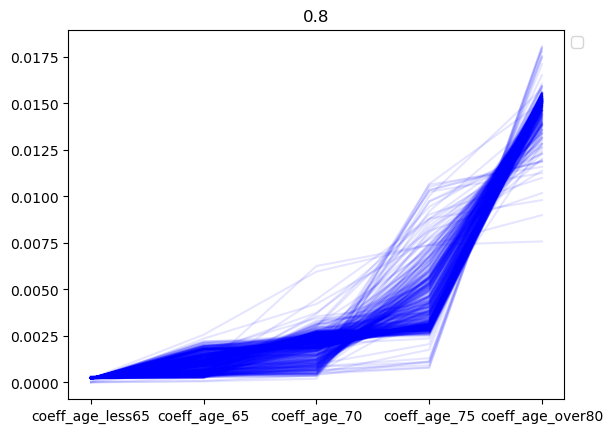

In [324]:
age_cols_to_plot = [c for c in df_admissions_lines_very_many.columns if (('coeff_age' in c) & ('start' not in c))]

quantile_min_list = df_admissions_lines_very_many['depriv_quantile_min'].unique()

for quantile_min in quantile_min_list:
    mask = (
        (df_admissions_lines_very_many['depriv_quantile_min'] == quantile_min) & 
        (df_admissions_lines_very_many['opt_coeffs_sorted_by_age'] == True)
    )
    
    df = df_admissions_lines_very_many.filter(mask)
    df = df.sort('rsquared')

    display(df)

    # display(df[['depriv_quantile_min'] + age_cols_to_plot])
    
    df = df[age_cols_to_plot].transpose()

    
    fig, ax = plt.subplots()
    for i, row in enumerate(df):
        ax.plot(row, color='b', alpha=0.1)#, label=quantile_mins[i])
    
    ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
    ax.set_xticks(np.arange(len(row)))
    ax.set_xticklabels(age_cols_to_plot)
    ax.set_title(quantile_min)
    plt.show()
    


### Check accuracy

Predict admissions from real data to see how good these coefficients are.

In [62]:
def calculate_admissions_from_health(df_stats, df_admissions_lines, cols_age):
    # Make a copy of the MSOA data:
    cols_to_keep = ['MSOA', 'IMD2019Score', 'admissions'] + props_health + cols_age
    df_p_admissions = df_stats[cols_to_keep]
    # Make column for the results with a placeholder value:
    col_admissions_pred = 'admissions_predicted'
    df_p_admissions = df_p_admissions.with_columns(pl.lit(0).alias(col_admissions_pred))
    
    for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
        # Pick out the bin edges:
        q0 = dict_quantiles[quantile]
        q1 = dict_quantiles[list(dict_quantiles.keys())[q+1]]
        # Find a mask for the demographic data that contains
        # only MSOA with IMD scores in this bin.
        mask = (df_p_admissions['IMD2019Score'] >= q0) & (df_p_admissions['IMD2019Score'] < q1)
        if q == len(dict_quantiles) - 2:
            # Also allow values at the right edge of the final bin.
            mask = mask | (df_p_admissions['IMD2019Score'] == q1)
    
        # Pick out the line parameters for this IMD:
        mask_coeffs = ((df_admissions_lines['imd_bin_min'] == q0))
        # coeff_good = df_admissions_lines.filter(mask_coeffs)['coeff_good_health'].to_numpy()[0]
        # coeff_fair = df_admissions_lines.filter(mask_coeffs)['coeff_fair_health'].to_numpy()[0]
        # coeff_bad = df_admissions_lines.filter(mask_coeffs)['coeff_bad_health'].to_numpy()[0]

        age_coeffs = [df_admissions_lines.filter(mask_coeffs)[f'coeff_{a}'].to_numpy()[0] for a in cols_age]
        summed_data = sum([age_coeffs[i] * df_p_admissions[a] for i, a in enumerate(cols_age)])
        # Calculate new props:
        df_p_admissions = df_p_admissions.with_columns(
            pl.when((mask))
            .then(summed_data)  # replace with calculated values
            .otherwise(pl.col(col_admissions_pred))  # otherwise keep the existing value
            .name.keep()
        )
    return df_p_admissions[['MSOA', 'admissions', col_admissions_pred]]

In [63]:
df_admissions_pred_from_real = calculate_admissions_from_health(df_stats, df_admissions_lines, age_numbers)

Check results:

In [64]:
df_admissions_pred_from_real.head()

MSOA,admissions,admissions_predicted
str,f64,f64
"""Adur 001""",14.333333,14.590912
"""Adur 002""",7.333333,10.748814
"""Adur 003""",9.333333,11.718655
"""Adur 004""",21.0,18.388883
"""Adur 005""",13.666667,14.187017


Calculate r-squared of this fit:

In [65]:
rsq = calculate_rsquared(
    df_admissions_pred_from_real['admissions'],
    df_admissions_pred_from_real['admissions_predicted']
)

rsq

0.5990794655132967

Plot predicted vs real admission numbers:

40.333333332


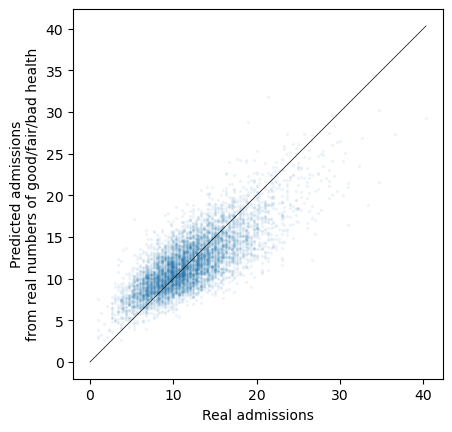

In [66]:
fig, ax = plt.subplots()

# Find max across both datasets:
ad_max = df_admissions_pred_from_real[['admissions', 'admissions_predicted']].max().max_horizontal().to_numpy()[0]
print(ad_max)

# Equal line:
ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)
# Data:
ax.scatter(
    df_admissions_pred_from_real['admissions'],
    df_admissions_pred_from_real['admissions_predicted'],
    s=2, alpha=0.05
)

ax.set_xlabel('Real admissions')
ax.set_ylabel('Predicted admissions\nfrom real numbers of good/fair/bad health')
ax.set_aspect('equal')
plt.show()

40.333333332


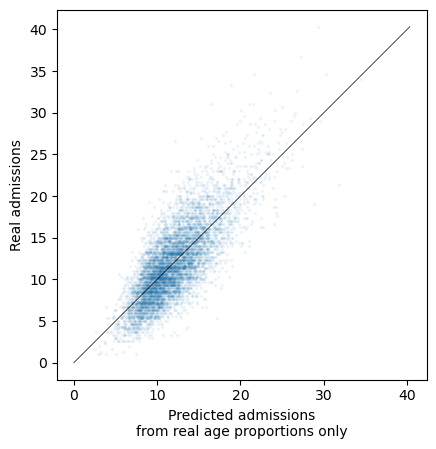

In [67]:
fig, ax = plt.subplots()

# Find max across both datasets:
ad_max = df_admissions_pred_from_real[['admissions_predicted', 'admissions']].max().max_horizontal().to_numpy()[0]
print(ad_max)

# Equal line:
ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)
# Data:
ax.scatter(
    df_admissions_pred_from_real['admissions_predicted'],
    df_admissions_pred_from_real['admissions'],
    s=2, alpha=0.05
)

ax.set_ylabel('Real admissions')
ax.set_xlabel('Predicted admissions\nfrom real age proportions only')
ax.set_aspect('equal')

plt.savefig(os.path.join('images', 'admissions_scatter_predicted_vs_real_imd5_from_real_age_props_only.png'), bbox_inches='tight')
plt.show()

### Check consistency of errors by IMD band

Split by IMD score:

In [68]:
df_admissions_pred_from_real = df_admissions_pred_from_real.join(df_stats[['MSOA', 'IMD2019Score', 'imd_bin_min']], on='MSOA')

In [69]:
df_admissions_pred_from_real.head()

MSOA,admissions,admissions_predicted,IMD2019Score,imd_bin_min
str,f64,f64,f64,f64
"""Adur 001""",14.333333,14.590912,16.924833,15.2564
"""Adur 002""",7.333333,10.748814,6.4704,2.2122
"""Adur 003""",9.333333,11.718655,13.7334,10.369
"""Adur 004""",21.0,18.388883,26.199857,21.81475
"""Adur 005""",13.666667,14.187017,11.7948,10.369


Plot all IMD bands on one axis:

40.333333332


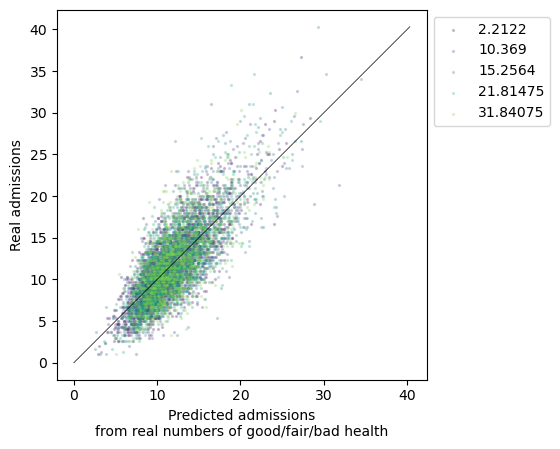

In [70]:
colours = plt.get_cmap('viridis')(np.linspace(0, 1, len(dict_quantiles)))

fig, ax = plt.subplots()

# Find max across both datasets:
ad_max = df_admissions_pred_from_real[['admissions_predicted', 'admissions']].max().max_horizontal().to_numpy()[0]
print(ad_max)

# Equal line:
ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)

for q, q0 in enumerate(list(dict_quantiles.values())[:-1]):
    
    mask = df_admissions_pred_from_real['imd_bin_min'] == q0
    df_here = df_admissions_pred_from_real.filter(mask)
    ax.scatter(df_here['admissions_predicted'], df_here['admissions'], color=colours[q], s=2, alpha=0.2, label=q0)

ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
ax.set_ylabel('Real admissions')
ax.set_xlabel('Predicted admissions\nfrom real numbers of good/fair/bad health')
ax.set_aspect('equal')
plt.show()

Errors look pretty consistent across IMD bands.

To check, split IMD bands into their own axes:

40.333333332


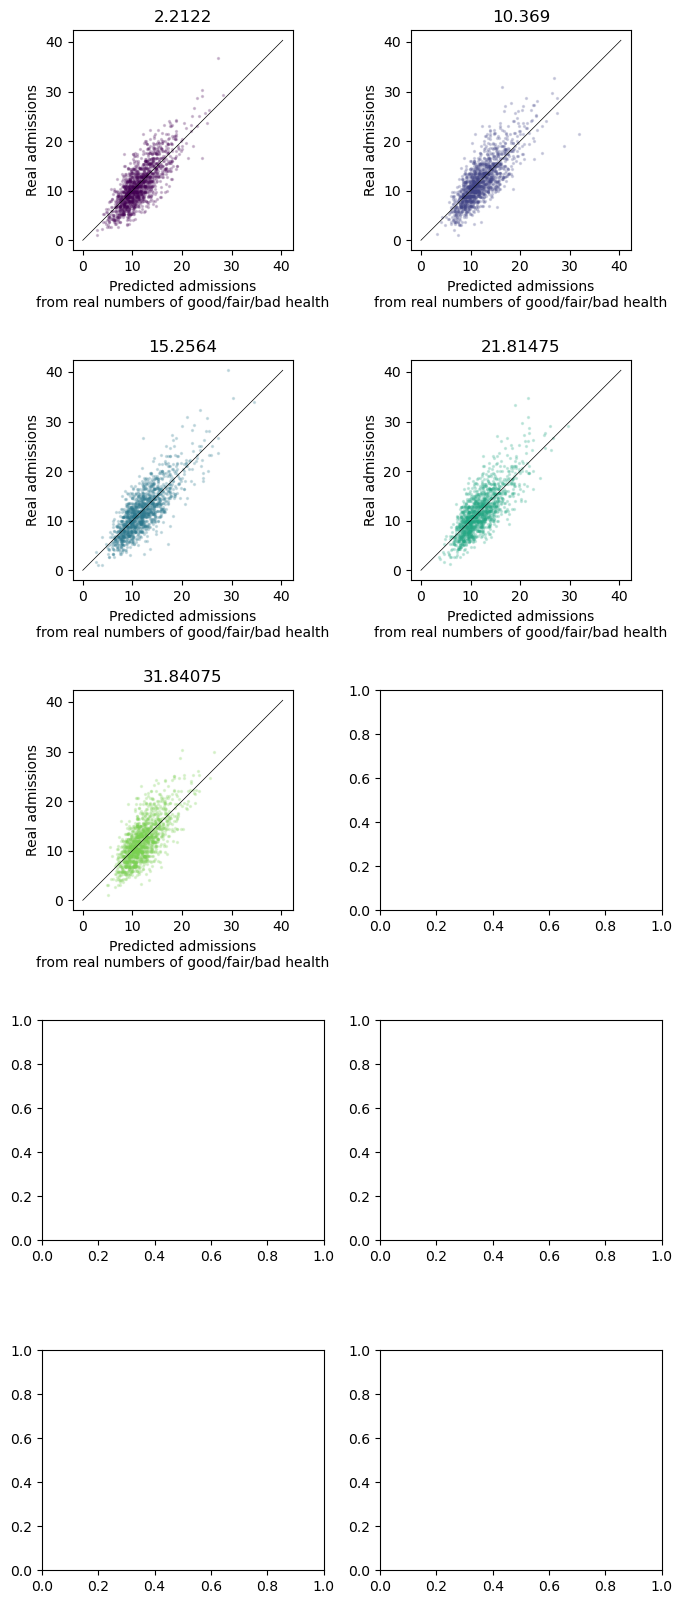

In [71]:
colours = plt.get_cmap('viridis')(np.linspace(0, 1, len(dict_quantiles)))

# fig, ax = plt.subplots()
n_cols = 2
n_rows = 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(8, 20), gridspec_kw={'hspace': 0.5})

# Find max across both datasets:
ad_max = df_admissions_pred_from_real[['admissions_predicted', 'admissions']].max().max_horizontal().to_numpy()[0]
print(ad_max)

# # Equal line:
# ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)

for q, q0 in enumerate(list(dict_quantiles.values())[:-1]):

    row = q % n_cols
    col = q // n_cols
    ax = axs[col, row]
    
    # Equal line:
    ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)
    
    mask = df_admissions_pred_from_real['imd_bin_min'] == q0
    df_here = df_admissions_pred_from_real.filter(mask)
    ax.scatter(df_here['admissions_predicted'], df_here['admissions'], color=colours[q], s=2, alpha=0.2, label=q0)

    # ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
    ax.set_ylabel('Real admissions')
    ax.set_xlabel('Predicted admissions\nfrom real numbers of good/fair/bad health')
    ax.set_aspect('equal')
    ax.set_title(q0)
plt.show()

Errors in predicted admission numbers don't depend on IMD band.

## Poisson distribution

In [72]:
# Set up random number generator object:
seed = 42
rng = np.random.default_rng(seed)

1 1.0 0.9497303885161422 0.7727840750057837
2 1.4142135623730951 1.9849643107606707 1.378297903702997
3 1.7320508075688772 2.8920321579003456 1.7655469643969235
4 2.0 4.204980983930081 2.0156891408357676
5 2.23606797749979 4.899635134650429 2.2114691334476153
6 2.449489742783178 5.776211007901078 2.542093152524914
7 2.6457513110645907 6.7042913942075355 2.7512843086859617
8 2.8284271247461903 8.108326541029719 2.7832048716014914
9 3.0 8.507260514288932 3.0072388122100553
10 3.1622776601683795 10.334541599158472 3.151287061911939
11 3.3166247903554 11.175057159757264 3.012888014813995
12 3.4641016151377544 11.89358132754504 3.5326109656566147
13 3.605551275463989 12.756434790535893 3.6916631930108768
14 3.7416573867739413 13.910238503021363 4.114945327354796
15 3.872983346207417 15.193130894350205 4.007396528609743
16 4.0 15.01393623800551 4.079206913090067
17 4.123105625617661 16.801116872022945 4.220354788801798
18 4.242640687119285 17.394128933563817 4.30385413934477
19 4.35889894354

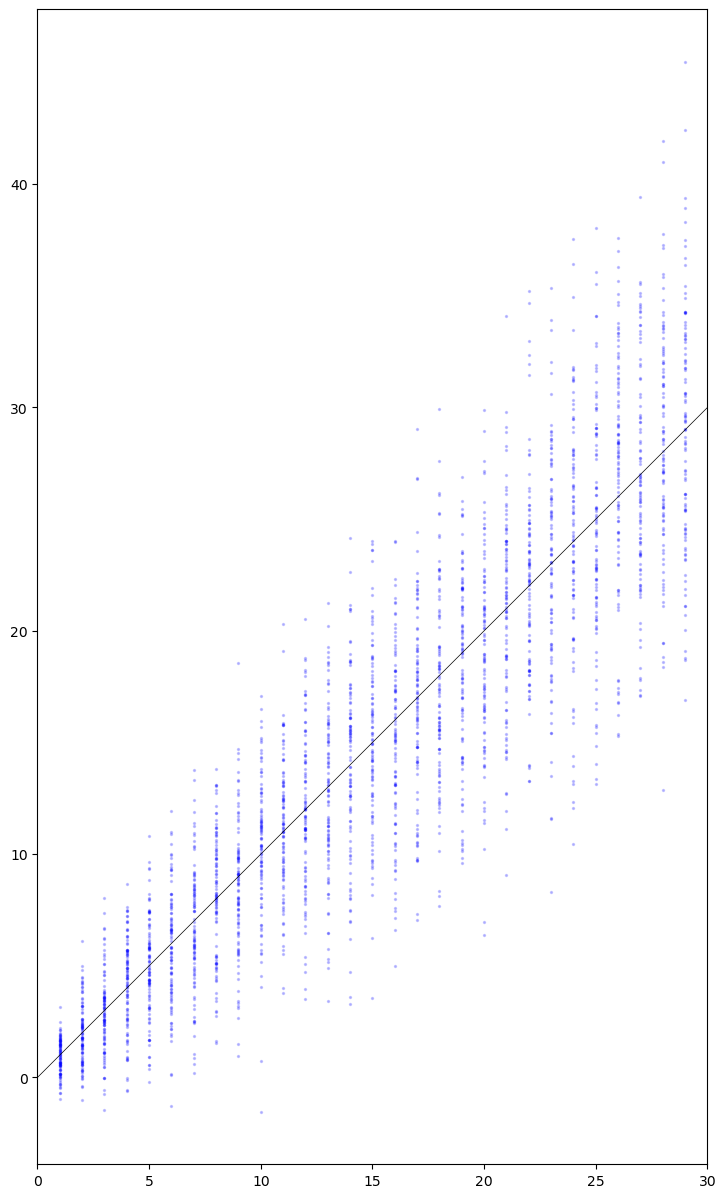

In [73]:

fig, ax = plt.subplots(figsize=(15, 15))

for i in range(1, 30, 1):
    # s = rng.poisson(i, 100)
    s = rng.normal(i, scale=np.sqrt(i), size=100)
    print(i, np.sqrt(i), s.mean(), s.std())

    # count, bins, ignored = ax.hist(s, 14, density=True)
    ax.scatter([i]*len(s), s, color='b', s=2, alpha=0.2)

ax.plot([0, 30], [0, 30], color='k', linewidth=0.5)
ax.set_xlim(0, 30)
ax.set_aspect('equal')
plt.show()

## Grid 2

In [42]:
start_options_by_coeff = [
    np.arange(1e-4, 8e-4, 1e-4),
    np.concatenate((np.arange(7e-4, 1e-3, 1e-4), np.arange(1e-3, 1e-2, 1e-3))),
    np.concatenate((np.arange(6e-4, 9.9e-4, 1e-4), np.arange(1e-3, 7e-3, 1e-3))),
    np.concatenate((np.arange(7e-4, 1e-3, 1e-4), np.arange(1e-3, 1e-2, 1e-3))),
    np.arange(1.2e-2, 2.0e-2, 1e-3),
]

In [43]:
start_options_by_coeff

[array([8.e-05, 9.e-05, 1.e-04, 2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04,
        7.e-04]),
 array([0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 ,
        0.006 , 0.007 , 0.008 , 0.009 ]),
 array([0.0006, 0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 ,
        0.005 , 0.006 ]),
 array([0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 ,
        0.006 , 0.007 , 0.008 , 0.009 ]),
 array([0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])]

Generate all combinations of these starting params:

In [44]:
import itertools

all_start_options_by_coeff = list(itertools.product(*start_options_by_coeff))

all_start_options_by_coeff[:5]

[(8e-05, 0.0007, 0.0006, 0.0007, 0.012),
 (8e-05, 0.0007, 0.0006, 0.0007, 0.013000000000000001),
 (8e-05, 0.0007, 0.0006, 0.0007, 0.014000000000000002),
 (8e-05, 0.0007, 0.0006, 0.0007, 0.015000000000000003),
 (8e-05, 0.0007, 0.0006, 0.0007, 0.016000000000000004)]

Place these into a DataFrame:

In [45]:
pl.DataFrame(all_start_options_by_coeff, orient='row', schema=[c for c in age_numbers])

age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64
0.00008,0.0007,0.0006,0.0007,0.012
0.00008,0.0007,0.0006,0.0007,0.013
0.00008,0.0007,0.0006,0.0007,0.014
0.00008,0.0007,0.0006,0.0007,0.015
0.00008,0.0007,0.0006,0.0007,0.016
…,…,…,…,…
0.0007,0.009,0.006,0.009,0.015
0.0007,0.009,0.006,0.009,0.016
0.0007,0.009,0.006,0.009,0.017


For each set of starting coefficients, find the r^2 of their predicted admissions fits and then find the optimised coefficients and their r^2 fit.

In [46]:
# Store the results in this list:
list_dict_coeffs = []

for ind_start, age_coeffs in enumerate(all_start_options_by_coeff):
    print(f'{ind_start:8.0f}', end='\r')
    q = 0
    for quantile_right_prop, quantile_left in imd_bin_left_edges.items():
        mask = (df_stats['imd_bin_min'] == quantile_left)
        quantile_right = dict_quantiles[list(dict_quantiles.keys())[q + 1]]
        quantile_left_prop = list(dict_quantiles.keys())[q + 1]
        # Keep only those MSOA:
        df_stats_here = df_stats.filter(mask)
    
        # MSOA data in the same order as those coefficients:
        x_lists = [df_stats_here[a] for a in age_numbers]
        # x_lists = [df_stats_here['good_health'], df_stats_here['fair health'], df_stats_here['bad health']]
        # Data for the optimiser function that should not be changed:
        args = [
            x_lists,
            df_stats_here['admissions']
        ]

        # Results without optimisation:
        admissions_predicted = predict_admissions(x_lists, np.array(age_coeffs))
        r2_without_opt = calculate_rsquared(df_stats_here['admissions'], admissions_predicted)

        # Store the results in a dictionary:
        dict_admissions_lines = {}
        dict_admissions_lines['start_option'] = ind_start
        dict_admissions_lines['depriv_quantile_min'] = quantile_left_prop
        dict_admissions_lines['depriv_quantile_max'] = quantile_right_prop
        # dict_admissions_lines['imd_bin_min'] = quantile_left
        # dict_admissions_lines['imd_bin_max'] = quantile_right
        for i, a in enumerate(age_numbers):
            dict_admissions_lines[f'coeff_{a}'] = round(age_coeffs[i], 7)
        dict_admissions_lines['rsquared'] = r2_without_opt
        # Store in big list of all results:
        list_dict_coeffs.append(dict_admissions_lines)
        # Iterate for next go round the loop:
        q += 1

# Convert the list of dicts into a dataframe:
df_coeffs_grid = pl.from_dicts(list_dict_coeffs)

In [61]:
df_coeffs_grid.write_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_postopt.csv'))

In [62]:
df_coeffs_grid.sort('start_option')

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64
23040,0.8,1.0,0.0001,0.0007,0.0006,0.0007,0.012,-0.319585
23040,0.6,0.8,0.0001,0.0007,0.0006,0.0007,0.012,-0.727782
23040,0.4,0.6,0.0001,0.0007,0.0006,0.0007,0.012,-0.883591
23040,0.2,0.4,0.0001,0.0007,0.0006,0.0007,0.012,-1.567636
23040,0.0,0.2,0.0001,0.0007,0.0006,0.0007,0.012,-2.689707
…,…,…,…,…,…,…,…,…
103679,0.8,1.0,0.0007,0.009,0.006,0.009,0.019,-6.686296
103679,0.6,0.8,0.0007,0.009,0.006,0.009,0.019,-5.244426
103679,0.4,0.6,0.0007,0.009,0.006,0.009,0.019,-3.361456


In [64]:
df_coeffs_grid['start_option'].max()

103679

In [48]:
print(stop, here, please)

NameError: name 'stop' is not defined